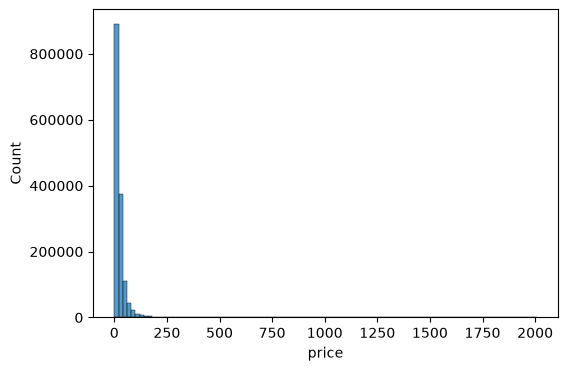

전처리 전 : (1482535, 8)
가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : (1481658, 8)
train_id 제거 및 중복 제거 후 : (1481609, 7)


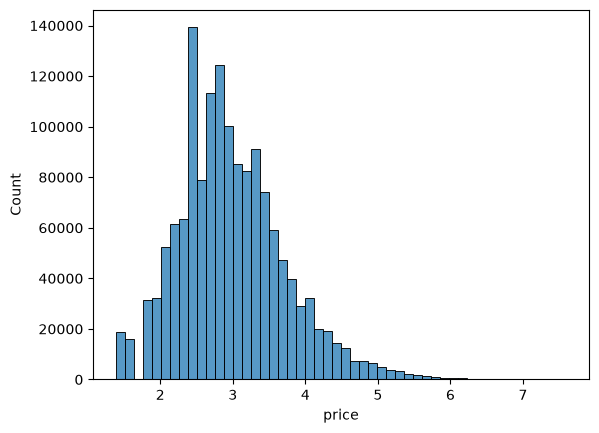

In [23]:
#데이터 불러오기

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

RANDOM_STATE = 42  # 재현성을 위해 랜덤값 고정

mercari_df = pd.read_csv('../../data/mercari_train.tsv', sep='\t')

# 가격 분포 확인
y_labels = mercari_df['price']
plt.figure(figsize=(6, 4))
sns.histplot(y_labels, bins=100)
plt.show()

mercari_df.value_counts('price').sort_index()

# 가격 이상치 처리
# 1) 0원 이하: 무효 데이터라 제거
# 2) 2000달러 초과: Mercari 플랫폼의 실제 최대 등록가 정책(도메인 규칙) 기준 제거 - 0원 처리와 동일한 원칙
print(f'전처리 전 : {mercari_df.shape}')

mercari_df = mercari_df[(mercari_df['price'] > 0) & (mercari_df['price'] <= 2000)]
print(f'가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거 + 중복 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)
print(f'train_id 제거 및 중복 제거 후 : {mercari_df.shape}')

# 가격 로그 변환 (분포가 크게 치우쳐 있어 log1p 적용, 예측 후 expm1로 원래 스케일 복원 예정)
y_labels = mercari_df['price']
mercari_df['price'] = np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [24]:
# category_name 3단계 분리 (Main/Sub/SubSub) - 구조적 파싱이라 split 이전에 해도 leakage 없음
def split_category(df, col='category_name'):
    df = df.copy()
    df[col] = df[col].fillna('Unknown/Unknown/Unknown')
    parts = df[col].str.split('/', n=2, expand=True)
    parts.columns = ['cat_main', 'cat_sub', 'cat_sub2']
    parts = parts.fillna('Unknown')  # 3단계가 안 나온 행 보정
    return pd.concat([df, parts], axis=1)

mercari_df = split_category(mercari_df)
mercari_df[['category_name', 'cat_main', 'cat_sub', 'cat_sub2']].head()

,category_name,cat_main,cat_sub,cat_sub2
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


In [25]:
# 학습 / 테스트 데이터 분리
# 실제 test.tsv(정답 없는 제출용)가 아니라, 보유한 train 데이터를 직접 나눠서 검증에 사용한다.
# 이 시점 이후의 모든 "학습(fit)" 단계는 train_df에서만 수행하고 test_df에는 적용(transform)만 한다.
train_df, test_df = train_test_split(
    mercari_df, test_size=0.2, random_state=RANDOM_STATE
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'train_df : {train_df.shape}')
print(f'test_df  : {test_df.shape}')

train_df : (1185287, 10)
test_df  : (296322, 10)


In [26]:
# brand_name 결측치 채우기 - item_description 우선, 그래도 못 찾으면 name(상품명)에서도 탐색 (2단계 매칭)
# 어디서 채워졌는지 brand_source 컬럼에 기록해서 나중에 신뢰도 구분/표본 검증에 활용
# 주의: 아직 텍스트를 불용어 제거/토큰화하기 전(원문에 가까운 상태)에 매칭해야
#       "Kate Spade"처럼 여러 단어로 된 브랜드명이나 특수문자가 포함된 브랜드명이 깨지지 않는다.

def build_known_brands(df, col='brand_name'):
    """train 데이터에서만 호출해야 함 - 이미 채워진 값들로 알려진 브랜드 목록 생성"""
    return sorted(df[col].dropna().unique().tolist())

def build_brand_pattern(known_brands):
    """긴 브랜드명이 먼저 매칭되도록 길이 내림차순 정렬 + 단어 경계(\\b) 정규식 컴파일"""
    sorted_brands = sorted([b for b in known_brands if len(b) > 0], key=len, reverse=True)
    escaped = [re.escape(b.lower()) for b in sorted_brands]
    pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b')
    lower_to_original = {b.lower(): b for b in sorted_brands}
    return pattern, lower_to_original

def fill_brand_with_source(df, pattern, lower_to_original, desc_col,
                            brand_col='brand_name', source_col='brand_source'):
    """brand_col이 NaN인 행에 대해서만 desc_col에서 브랜드를 탐색해 채우고,
    새로 채워진 행에는 source_col에 desc_col 이름을 기록한다 (매칭 출처 추적용)."""
    df = df.copy()
    missing_mask = df[brand_col].isna()

    def find_brand(text):
        match = pattern.search(str(text).lower())
        if match:
            return lower_to_original[match.group(1)]
        return None

    found = df.loc[missing_mask, desc_col].fillna('').apply(find_brand)
    df.loc[missing_mask, brand_col] = found

    newly_filled_mask = missing_mask & df[brand_col].notna()
    df.loc[newly_filled_mask, source_col] = desc_col
    return df

# 1) train에서만 브랜드 사전 생성 (leakage 방지)
known_brands = build_known_brands(train_df)
brand_pattern, brand_lower_to_original = build_brand_pattern(known_brands)
print(f'train 기준 알려진 브랜드 수 : {len(known_brands)}')

# 2) brand_source 초기화 - 원래 값이 있던 행은 'original', 없는 행은 일단 'unmatched'
train_df['brand_source'] = np.where(train_df['brand_name'].notna(), 'original', 'unmatched')

# 3) 1차: item_description에서 매칭
train_df = fill_brand_with_source(train_df, brand_pattern, brand_lower_to_original, desc_col='item_description')

# 4) 2차: 1차에서도 못 찾은 행만 name(상품명)에서 매칭
train_df = fill_brand_with_source(train_df, brand_pattern, brand_lower_to_original, desc_col='name')

print(train_df['brand_source'].value_counts())

# 5) 사전을 파일로 저장해두고 test/향후 데이터에는 이 파일을 불러와 "적용만" 한다
with open('brand_dictionary.pkl', 'wb') as f:
    pickle.dump(known_brands, f)

train 기준 알려진 브랜드 수 : 4535
brand_source
original            679614
item_description    309632
unmatched           130989
name                 65052
Name: count, dtype: int64


In [27]:
# test_df에는 train에서 만든 사전을 "적용만" 한다 (사전을 새로 만들지 않음)
# train과 동일하게 brand_source 초기화 + 2단계 매칭(item_description → name) 적용
test_df['brand_source'] = np.where(test_df['brand_name'].notna(), 'original', 'unmatched')
test_df = fill_brand_with_source(test_df, brand_pattern, brand_lower_to_original, desc_col='item_description')
test_df = fill_brand_with_source(test_df, brand_pattern, brand_lower_to_original, desc_col='name')

print(test_df['brand_source'].value_counts())

# train 사전에 없는 브랜드는 test에서 원래 값으로 존재했든 description/name 매칭으로 채워졌든
# 전부 'Unknown'으로 통일한다 (인코딩 단계의 unseen category 문제 방지)
# brand_source는 "어디서 찾았는지" 기록이라 이 Unknown 통일과는 별개로 그대로 유지한다.
known_brands_set = set(known_brands)

def restrict_to_known(series, known_set, unknown_value='Unknown'):
    return series.where(series.isin(known_set) & series.notna(), unknown_value)

train_df['brand_name'] = restrict_to_known(train_df['brand_name'], known_brands_set)
test_df['brand_name'] = restrict_to_known(test_df['brand_name'], known_brands_set)

# category_name도 동일한 원칙 적용: train에 등장한 조합만 known set으로 인정
for col in ['cat_main', 'cat_sub', 'cat_sub2']:
    known_cats = set(train_df[col].unique())
    test_df[col] = restrict_to_known(test_df[col], known_cats)

print('brand_name 결측치 (train):', train_df['brand_name'].isna().sum())
print('brand_name 결측치 (test) :', test_df['brand_name'].isna().sum())
print(train_df['brand_name'].value_counts().head())

brand_source
original            169700
item_description     77904
unmatched            32371
name                 16347
Name: count, dtype: int64
brand_name 결측치 (train): 0
brand_name 결측치 (test) : 0
brand_name
Unknown    130989
AND        103347
PINK        58226
Nike        44823
LuLaRoe     42485
Name: count, dtype: int64


In [28]:
# 오탐 브랜드 스크리닝 - "매칭 비율" 계산
# 진짜 브랜드라면 원래(original)도 어느 정도 있어야 정상. 'and'처럼 흔한 단어는
# original은 적은데 description/name 매칭으로만 폭발적으로 늘어나는 특징을 보임 -> 이 비율로 자동 스크리닝.
combined = pd.concat([train_df, test_df])

brand_source_by_brand = (
    combined.groupby(['brand_name', 'brand_source']).size().unstack(fill_value=0)
)
for col in ['original', 'item_description', 'name']:
    if col not in brand_source_by_brand.columns:
        brand_source_by_brand[col] = 0

brand_source_by_brand['matched_total'] = brand_source_by_brand['item_description'] + brand_source_by_brand['name']
brand_source_by_brand['매칭배율'] = brand_source_by_brand['matched_total'] / (brand_source_by_brand['original'] + 1)

# 여러 단어로 된 브랜드(예: Kate Spade)는 우연히 통째로 매칭될 확률이 낮아 상대적으로 안전 -> 한 단어짜리만 스크리닝
single_word_brands = [b for b in brand_source_by_brand.index if isinstance(b, str) and ' ' not in b and b != 'Unknown']
suspects = brand_source_by_brand.loc[single_word_brands].sort_values('매칭배율', ascending=False)

print(suspects[['original', 'item_description', 'name', 'matched_total', '매칭배율']].head(20))

brand_source  original  item_description  name  matched_total          매칭배율
brand_name                                                                 
AND                  3            124566  4954         129520  32380.000000
BLUE                 1             11712  1715          13427   6713.500000
X                    1              5750   337           6087   3043.500000
Ask                  1              5195     3           5198   2599.000000
Silver               3              9342  1042          10384   2596.000000
Diamond              1              1371   347           1718    859.000000
Key                  1               873   162           1035    517.500000
Complete             2              1337   132           1469    489.666667
Tag                 12              6255    54           6309    485.307692
Pro                  2               925   303           1228    409.333333
Sure                 4              1987     2           1989    397.800000
CLEAN       

In [29]:
# 추가 feature 1: 설명 유무 플래그 / 텍스트 길이
# 반드시 텍스트 클렌징(토큰화) 이전, 원문 상태에서 계산해야 함
for df in (train_df, test_df):
    df['has_description'] = (
        df['item_description'].fillna('No description yet') != 'No description yet'
    ).astype(int)
    df['name_len'] = df['name'].fillna('').apply(lambda x: len(str(x).split()))
    df['desc_len'] = df['item_description'].fillna('No description yet').apply(lambda x: len(str(x).split()))

print(train_df[['has_description', 'name_len', 'desc_len']].describe())

       has_description      name_len      desc_len
count     1.185287e+06  1.185287e+06  1.185287e+06
mean      9.444759e-01  4.400638e+00  2.567726e+01
std       2.290005e-01  1.654930e+00  3.038149e+01
min       0.000000e+00  1.000000e+00  1.000000e+00
25%       1.000000e+00  3.000000e+00  7.000000e+00
50%       1.000000e+00  4.000000e+00  1.500000e+01
75%       1.000000e+00  6.000000e+00  3.100000e+01
max       1.000000e+00  1.700000e+01  2.450000e+02


In [30]:
# 텍스트 전처리 유틸 함수 (item_description, name 공통 사용)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def text_cleaning(text):
    # 소문자로 변환
    text = text.lower()
    # 영문자/숫자/공백을 제외한 문자 제거 ([rm] 마스킹 토큰의 대괄호도 여기서 제거됨)
    # 숫자는 제거하지 않음 - 4gb, 32gb, 사이즈 등 가격에 영향을 줄 수 있는 정보라 보존
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
# (버그 수정: 기존 코드는 'never'와 'without' 사이에 콤마가 빠져 있어서
#  파이썬이 두 문자열을 'neverwithout' 하나로 합쳐버렸음 -> 콤마 추가로 수정)
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}
stop_words = stop_words - negative_words

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

def preprocess_text(text):
    # 1. 소문자 / 영문자 / 숫자 / 공백 정리
    text = text_cleaning(text)
    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)
    # 3. 불용어 제거
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [31]:
# item_description, name 클렌징 적용 (train_df, test_df 각각에 동일하게 적용 - 순수 per-row 변환이라 leakage 없음)
# 데이터 규모가 커서 시간이 다소 걸릴 수 있음 (수 분 단위)

def clean_text_columns(df):
    df = df.copy()
    df['item_description'] = df['item_description'].fillna('No description yet').astype(str)
    df['name'] = df['name'].fillna('').astype(str)

    df['item_description'] = df['item_description'].apply(preprocess_text).apply(lambda x: ' '.join(x))
    df['name'] = df['name'].apply(preprocess_text).apply(lambda x: ' '.join(x))
    return df

train_df = clean_text_columns(train_df)
test_df = clean_text_columns(test_df)

train_df[['name', 'item_description']].head()

,name,item_description
0,forever 21 sundress,nwts forever 21 purple sundress shoulder size
1,bundle pants,bundle pants good condition except green ones ...
2,peach shirt free ship,size medium plain 3 4 sleeve peach colored top...
3,bundle kalislp,item worn no holes tears minor pulls
4,new bikini lot 2 sz sm free shipping,awesome brazilian bikinis one black one teal s...


In [32]:
# item_description / name 텍스트 벡터화 (TfidfVectorizer)
# 원칙: train으로만 fit(), test는 transform()만 - 새 단어는 에러 없이 그냥 무시됨
name_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
desc_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_name_train = name_vectorizer.fit_transform(train_df['name'])
X_name_test = name_vectorizer.transform(test_df['name'])

X_desc_train = desc_vectorizer.fit_transform(train_df['item_description'])
X_desc_test = desc_vectorizer.transform(test_df['item_description'])

print('name 벡터 shape       :', X_name_train.shape, X_name_test.shape)
print('description 벡터 shape:', X_desc_train.shape, X_desc_test.shape)

# 벡터라이저 객체 저장 (brand 사전과 동일한 관리 방식 - 재사용을 위해 fit된 객체 자체를 보존)
with open('name_vectorizer.pkl', 'wb') as f:
    pickle.dump(name_vectorizer, f)
with open('desc_vectorizer.pkl', 'wb') as f:
    pickle.dump(desc_vectorizer, f)

name 벡터 shape       : (1185287, 30000) (296322, 30000)
description 벡터 shape: (1185287, 50000) (296322, 50000)


In [33]:
# brand_name / category 원-핫 인코딩
# handle_unknown='ignore' -> train에 없던 값이 test에 나와도 에러 없이 전부 0벡터로 처리됨
# (이미 restrict_to_known으로 'Unknown' 통일까지 해뒀지만, 이중 안전장치로 추가)
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['brand_name', 'cat_main', 'cat_sub', 'cat_sub2']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cat_train = ohe.fit_transform(train_df[cat_cols])
X_cat_test = ohe.transform(test_df[cat_cols])

print('카테고리 원-핫 shape :', X_cat_train.shape, X_cat_test.shape)

with open('cat_encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)

카테고리 원-핫 shape : (1185287, 5527) (296322, 5527)


In [34]:
# 수치형 피처 스케일링 (item_condition_id + 신규 추가 feature 3개)
# GBM은 스케일에 둔감하지만 베이스라인 선형회귀(Ridge)를 위해 표준화한다.
# shipping은 이미 0/1 이진값이라 스케일링 대상에서 제외.
# brand_target_enc는 실험 결과(다중공선성 확인) 원-핫만 쓰는 것보다 안 좋아서 최종 제외함.
numeric_cols = ['item_condition_id', 'has_description', 'name_len', 'desc_len']

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_num_test = scaler.transform(test_df[numeric_cols])

print('수치형 스케일링 shape :', X_num_train.shape, X_num_test.shape)

with open('numeric_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

수치형 스케일링 shape : (1185287, 4) (296322, 4)


In [35]:
# 최종 feature 결합 + 전체 전처리 파이프라인을 하나로 묶기
from scipy.sparse import csr_matrix, hstack

def combine_features(X_cat, X_num, shipping_series, X_name, X_desc):
    X_ship = csr_matrix(shipping_series.values.reshape(-1, 1))
    return hstack([X_cat, X_num, X_ship, X_name, X_desc]).tocsr()

X_train = combine_features(X_cat_train, X_num_train, train_df['shipping'], X_name_train, X_desc_train)
X_test = combine_features(X_cat_test, X_num_test, test_df['shipping'], X_name_test, X_desc_test)

y_train = train_df['price'].values  # 이미 log1p 적용된 값
y_test = test_df['price'].values

print('X_train :', X_train.shape, ' X_test :', X_test.shape)

# 학습 때 사용한 모든 전처리 객체를 하나의 아티팩트로 묶어서 저장한다.
# -> 이후 새 상품 하나(또는 새 데이터셋)가 들어와도 이 파일 하나만 불러와서
#    preprocess_new_data()에 통과시키면 학습 때와 완전히 동일한 형식의 feature가 나온다.
pipeline_artifacts = {
    'known_brands': known_brands,
    'brand_pattern': brand_pattern,
    'brand_lower_to_original': brand_lower_to_original,
    'known_brands_set': known_brands_set,
    'known_cats': {col: set(train_df[col].unique()) for col in cat_cols},
    'stop_words': stop_words,
    'cat_encoder': ohe,
    'numeric_scaler': scaler,
    'name_vectorizer': name_vectorizer,
    'desc_vectorizer': desc_vectorizer,
    'numeric_cols': numeric_cols,
    'cat_cols': cat_cols,
}

with open('mercari_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_artifacts, f)


def preprocess_new_data(raw_df, artifacts=pipeline_artifacts):
    """새로 들어온 원본 데이터(raw_df)에 학습 때와 동일한 전처리를 그대로 적용해
    모델 입력용 희소행렬을 반환한다. (train 재학습 없이 저장된 아티팩트만 사용)"""
    df = raw_df.copy()

    # 1) category 3분할
    df = split_category(df)

    # 2) brand_name 결측치 채우기 - item_description 우선, 못 찾으면 name도 탐색 (train/test와 동일한 2단계 매칭)
    df['brand_source'] = np.where(df['brand_name'].notna(), 'original', 'unmatched')
    df = fill_brand_with_source(df, artifacts['brand_pattern'], artifacts['brand_lower_to_original'], desc_col='item_description')
    df = fill_brand_with_source(df, artifacts['brand_pattern'], artifacts['brand_lower_to_original'], desc_col='name')
    df['brand_name'] = restrict_to_known(df['brand_name'], artifacts['known_brands_set'])
    for col in ['cat_main', 'cat_sub', 'cat_sub2']:
        df[col] = restrict_to_known(df[col], artifacts['known_cats'][col])

    # 3) 추가 feature (has_description / 텍스트 길이) - 전부 원문 상태에서 계산
    #    brand_target_enc는 실험 결과 성능/해석 둘 다 원-핫만 쓰는 것보다 안 좋아서 최종 제외함.
    df['has_description'] = (df['item_description'].fillna('No description yet') != 'No description yet').astype(int)
    df['name_len'] = df['name'].fillna('').apply(lambda x: len(str(x).split()))
    df['desc_len'] = df['item_description'].fillna('No description yet').apply(lambda x: len(str(x).split()))

    # 4) 텍스트 클렌징 (name, item_description)
    df = clean_text_columns(df)

    # 5) 인코딩 / 벡터화 / 스케일링 (전부 transform만 수행)
    X_cat = artifacts['cat_encoder'].transform(df[artifacts['cat_cols']])
    X_num = artifacts['numeric_scaler'].transform(df[artifacts['numeric_cols']])
    X_name = artifacts['name_vectorizer'].transform(df['name'])
    X_desc = artifacts['desc_vectorizer'].transform(df['item_description'])

    return combine_features(X_cat, X_num, df['shipping'], X_name, X_desc)

X_train : (1185287, 85532)  X_test : (296322, 85532)


In [36]:
# 평가지표: RMSLE
# y_train/y_test가 이미 log1p(price)이므로, 로그 스케일에서의 RMSE가 곧 RMSLE와 수학적으로 동일하다.
# rmsle(price_pred, price_true) = sqrt(mean((log1p(price_pred)-log1p(price_true))^2))
#                                = sqrt(mean((pred_log - true_log)^2))  <- 이미 log1p된 값끼리 비교
from sklearn.metrics import mean_squared_error

def rmsle_on_log_scale(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [37]:
# 베이스라인 모델: Ridge 회귀
# feature가 85,529개라 과적합 방지용으로 L2 정규화가 있는 Ridge 사용
ridge = Ridge(alpha=1.0)  # alpha: 정규화 강도

ridge.fit(X_train, y_train)  # 계수 학습

ridge_pred = ridge.predict(X_test)  # 예측값 (아직 log1p 스케일)

ridge_rmsle = rmsle_on_log_scale(y_test, ridge_pred)  # log 스케일 RMSE = RMSLE

print(f'[Ridge baseline] RMSLE : {ridge_rmsle:.5f}')  # GBM과 비교할 기준점

[Ridge baseline] RMSLE : 0.45362


       version  ridge_rmsle
digits removed     0.458920
   digits kept     0.453622
차이: -0.00530  (digits kept가 더 좋음)


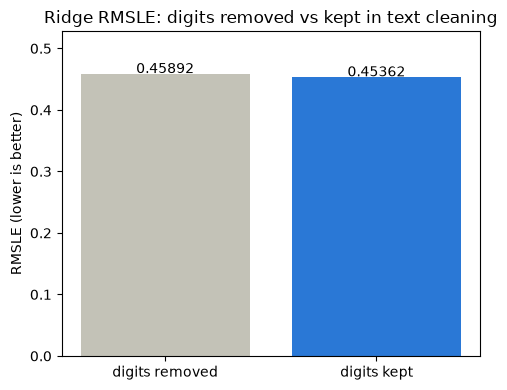

In [38]:
# 숫자 제거 vs 숫자 유지 - Ridge RMSLE 비교
# '숫자 유지'는 바로 위 Ridge 셀에서 방금 학습된 실제 ridge_rmsle 값 (현재 text_cleaning 기준).
# '숫자 제거'는 동일 파이프라인(train_test_split random_state=42, 동일 brand/category 전처리)에서
# text_cleaning 정규식만 [^a-z\s] (숫자 제거)로 되돌려 별도로 검증했던 결과값 (고정 기록값).
digit_removed_rmsle = 0.45892
digit_kept_rmsle = ridge_rmsle

comparison = pd.DataFrame({
    'version': ['digits removed', 'digits kept'],
    'ridge_rmsle': [digit_removed_rmsle, digit_kept_rmsle],
})
print(comparison.to_string(index=False))

diff = digit_kept_rmsle - digit_removed_rmsle
better = 'digits kept' if digit_kept_rmsle < digit_removed_rmsle else 'digits removed'
print(f'차이: {diff:+.5f}  ({better}가 더 좋음)')

plt.figure(figsize=(5, 4))
bars = plt.bar(comparison['version'], comparison['ridge_rmsle'], color=['#c3c2b7', '#2a78d6'])
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge RMSLE: digits removed vs kept in text cleaning')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001, f'{b.get_height():.5f}', ha='center')
plt.ylim(0, max(comparison['ridge_rmsle']) * 1.15)
plt.tight_layout()
plt.show()

alpha=1    RMSLE=0.45362
alpha=2    RMSLE=0.45245
alpha=3    RMSLE=0.45205
alpha=4    RMSLE=0.45201
alpha=5    RMSLE=0.45216

best alpha = 4.0 (RMSLE 0.45201)


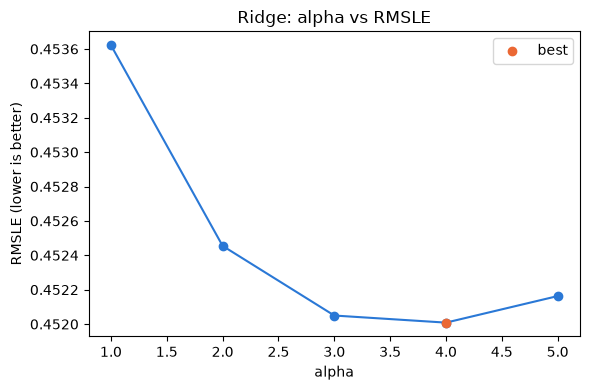

In [39]:
# Ridge alpha 값별 성능 비교 (1, 2, 3, 4, 5)
alphas = [1, 2, 3, 4, 5]
alpha_results = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    pred = r.predict(X_test)
    rmsle = rmsle_on_log_scale(y_test, pred)
    alpha_results.append({'alpha': a, 'rmsle': rmsle})
    print(f'alpha={a:<4} RMSLE={rmsle:.5f}')

alpha_df = pd.DataFrame(alpha_results)
best_row = alpha_df.loc[alpha_df['rmsle'].idxmin()]
print(f"\nbest alpha = {best_row['alpha']} (RMSLE {best_row['rmsle']:.5f})")

plt.figure(figsize=(6, 4))
plt.plot(alpha_df['alpha'], alpha_df['rmsle'], marker='o', color='#2a78d6')
plt.scatter([best_row['alpha']], [best_row['rmsle']], color='#eb6834', zorder=5, label='best')
plt.xlabel('alpha')
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge: alpha vs RMSLE')
plt.legend()
plt.tight_layout()
plt.show()

                           group  n_features  sum_abs_weight  mean_abs_weight
                     description       50000     8515.040342         0.170301
                            name       30000     5963.678397         0.198789
                      brand_name        4536      893.511581         0.196982
                        category         991      154.423707         0.155826
numeric (condition/has_desc/len)           4        0.225569         0.056392
                        shipping           1        0.185970         0.185970

          feature      coef
item_condition_id -0.086205
         name_len  0.073191
         desc_len  0.044399
  has_description  0.021774


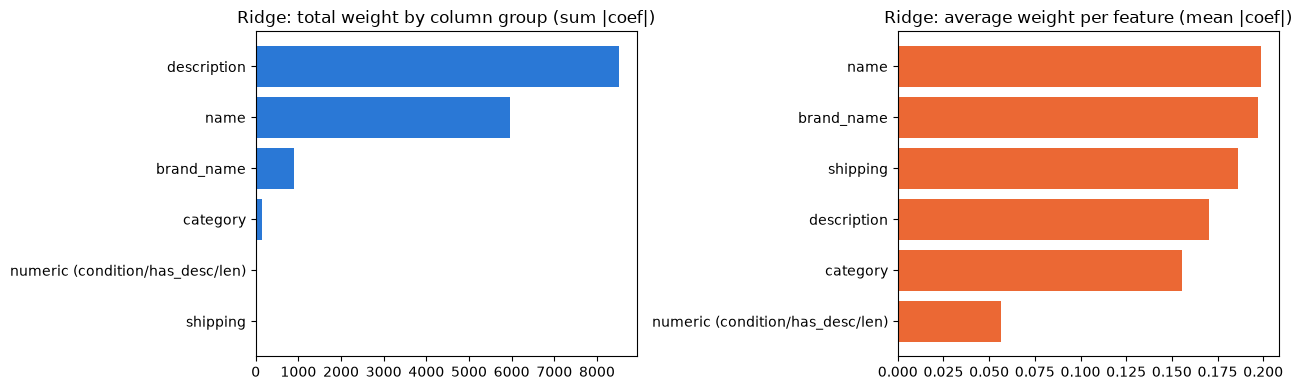

In [40]:
# Ridge 계수(coef_)를 6개 컬럼 그룹(brand_name / category / numeric / shipping / name / description)으로
# 묶어서 그룹별 대표 가중치를 확인한다. X_train을 hstack한 순서(cat, num, ship, name, desc) 그대로 슬라이싱.
# 'numeric' 그룹은 [item_condition_id, has_description, name_len, desc_len] 4개를 합친 블록이다.
# (brand_target_enc는 다중공선성 확인 실험 결과 제외했음)

cat_lengths = [len(c) for c in ohe.categories_]  # cat_cols = ['brand_name','cat_main','cat_sub','cat_sub2'] 순서
n_brand = cat_lengths[0]
n_category = sum(cat_lengths[1:])  # cat_main + cat_sub + cat_sub2 를 'category' 하나로 묶음

offset = 0
brand_coef = ridge.coef_[offset:offset+n_brand]; offset += n_brand
category_coef = ridge.coef_[offset:offset+n_category]; offset += n_category
numeric_coef = ridge.coef_[offset:offset+X_num_train.shape[1]]; offset += X_num_train.shape[1]
shipping_coef = ridge.coef_[offset:offset+1]; offset += 1
name_coef = ridge.coef_[offset:offset+X_name_train.shape[1]]; offset += X_name_train.shape[1]
desc_coef = ridge.coef_[offset:offset+X_desc_train.shape[1]]; offset += X_desc_train.shape[1]

assert offset == len(ridge.coef_), 'offset이 전체 계수 길이와 안 맞음 - 슬라이싱 순서 확인 필요'

groups = {
    'brand_name': brand_coef,
    'category': category_coef,
    'numeric (condition/has_desc/len)': numeric_coef,
    'shipping': shipping_coef,
    'name': name_coef,
    'description': desc_coef,
}

weight_summary = pd.DataFrame({
    'group': list(groups.keys()),
    'n_features': [len(v) for v in groups.values()],
    'sum_abs_weight': [np.abs(v).sum() for v in groups.values()],
    'mean_abs_weight': [np.abs(v).mean() for v in groups.values()],
}).sort_values('sum_abs_weight', ascending=False)

print(weight_summary.to_string(index=False))

# numeric 그룹 4개는 각각 개별 가중치도 따로 확인 (묶어놓으면 안 보이니까)
numeric_detail = pd.DataFrame({
    'feature': numeric_cols,
    'coef': numeric_coef,
}).sort_values('coef', key=np.abs, ascending=False)
print()
print(numeric_detail.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order1 = weight_summary.sort_values('sum_abs_weight')
axes[0].barh(order1['group'], order1['sum_abs_weight'], color='#2a78d6')
axes[0].set_title('Ridge: total weight by column group (sum |coef|)')

order2 = weight_summary.sort_values('mean_abs_weight')
axes[1].barh(order2['group'], order2['mean_abs_weight'], color='#eb6834')
axes[1].set_title('Ridge: average weight per feature (mean |coef|)')

plt.tight_layout()
plt.show()

[RidgeCV] best alpha = 3.1623  RMSLE = 0.45202
-> linear_cv_results.pkl 에 RidgeCV 결과 저장 완료
[LassoCV->Lasso] best alpha = 0.00010  RMSLE = 0.53942  (0이 아닌 계수 866 / 85,532)
-> linear_cv_results.pkl 에 LassoCV 결과 저장 완료
[ElasticNetCV->ElasticNet] best alpha = 0.00010, l1_ratio = 0.1  RMSLE = 0.49954  (0이 아닌 계수 8,993 / 85,532)
-> linear_cv_results.pkl 에 ElasticNetCV 결과 저장 완료

       model    rmsle
     RidgeCV 0.452025
     LassoCV 0.539420
ElasticNetCV 0.499537


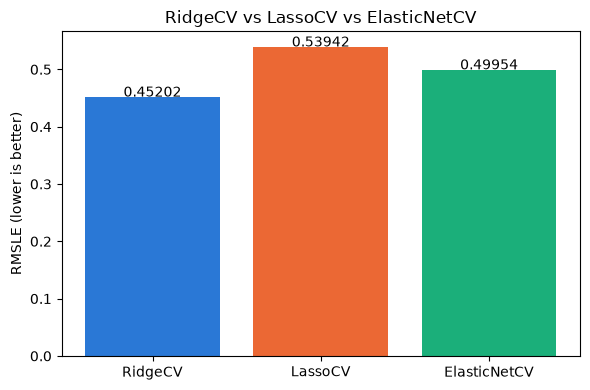

In [43]:
# RidgeCV로 최적 alpha 탐색 -> 그 결과를 바탕으로 LassoCV / ElasticNetCV 비교
# Lasso/ElasticNet은 좌표하강법(coordinate descent)이라 85,529차원 x 118만행에서 그대로 풀 CV 돌리면
# 매우 오래 걸릴 수 있음 -> FAST_CV_CHECK=True면 서브샘플로 먼저 alpha만 빠르게 찾고, 최종 fit만 전체 데이터로 함.
# + 중간에 멈춰도 이어서 할 수 있도록, 모델 하나가 끝날 때마다 결과를 pickle로 저장하고
#   다음에 다시 실행할 때 이미 저장된 게 있으면 재계산 없이 그대로 불러와서 건너뛴다.
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, Lasso, ElasticNet

FAST_CV_CHECK = True
CV_FOLDS = 3
N_ALPHAS = 15
SAMPLE_SIZE = 200000 if FAST_CV_CHECK else X_train.shape[0]  # Lasso/ElasticNet CV 탐색용 서브샘플 크기

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_train.shape[0], size=SAMPLE_SIZE, replace=False)
X_train_sample = X_train[sample_idx]
y_train_sample = y_train[sample_idx]

RESULTS_PATH = 'linear_cv_results.pkl'

# 이전에 중간까지 돌리고 저장해둔 결과가 있으면 불러와서 이어감 (없으면 빈 dict로 시작)
try:
    with open(RESULTS_PATH, 'rb') as f:
        results = pickle.load(f)
    print(f'저장된 결과 불러옴: {list(results.keys())}')
except FileNotFoundError:
    results = {}

def save_results():
    with open(RESULTS_PATH, 'wb') as f:
        pickle.dump(results, f)

# 1) RidgeCV - 닫힌 해가 있어서 빠름, 전체 데이터로 바로 탐색
if 'ridge_cv_rmsle' in results:
    ridge_cv = results['ridge_cv']
    ridge_cv_rmsle = results['ridge_cv_rmsle']
    print(f'[RidgeCV] (저장된 결과 재사용) best alpha = {ridge_cv.alpha_:.4f}  RMSLE = {ridge_cv_rmsle:.5f}')
else:
    ridge_alphas = np.logspace(-1, 2, N_ALPHAS)
    ridge_cv = RidgeCV(alphas=ridge_alphas, cv=CV_FOLDS, scoring='neg_mean_squared_error')
    ridge_cv.fit(X_train, y_train)
    ridge_cv_rmsle = rmsle_on_log_scale(y_test, ridge_cv.predict(X_test))
    print(f'[RidgeCV] best alpha = {ridge_cv.alpha_:.4f}  RMSLE = {ridge_cv_rmsle:.5f}')
    results['ridge_cv'] = ridge_cv
    results['ridge_cv_rmsle'] = ridge_cv_rmsle
    save_results()
    print(f'-> {RESULTS_PATH} 에 RidgeCV 결과 저장 완료')

# 2) LassoCV - 서브샘플로 alpha 경로 탐색 후, 찾은 alpha로 전체 데이터에 재학습
# 주의: n_alphas 인자가 현재 sklearn 버전에서는 LassoCV/ElasticNetCV 생성자에서 안 먹혀서(TypeError 발생),
#       RidgeCV와 동일하게 alphas= 배열을 직접 만들어 넘기는 방식으로 변경.
#       L1 alpha는 보통 L2(Ridge)보다 훨씬 작은 값에서 최적점이 나오는 경우가 많아 더 낮은 범위로 잡음.
if 'lasso_rmsle' in results:
    lasso_cv = results['lasso_cv']
    lasso_final = results['lasso_final']
    lasso_rmsle = results['lasso_rmsle']
    print(f'[LassoCV->Lasso] (저장된 결과 재사용) best alpha = {lasso_cv.alpha_:.5f}  RMSLE = {lasso_rmsle:.5f}')
else:
    lasso_alphas = np.logspace(-4, 1, N_ALPHAS)
    lasso_cv = LassoCV(alphas=lasso_alphas, cv=CV_FOLDS, random_state=RANDOM_STATE, max_iter=3000, n_jobs=-1)
    lasso_cv.fit(X_train_sample, y_train_sample)
    lasso_final = Lasso(alpha=lasso_cv.alpha_, max_iter=5000)
    lasso_final.fit(X_train, y_train)
    lasso_rmsle = rmsle_on_log_scale(y_test, lasso_final.predict(X_test))
    print(f'[LassoCV->Lasso] best alpha = {lasso_cv.alpha_:.5f}  RMSLE = {lasso_rmsle:.5f}'
          f'  (0이 아닌 계수 {np.sum(lasso_final.coef_ != 0):,} / {len(lasso_final.coef_):,})')
    results['lasso_cv'] = lasso_cv
    results['lasso_final'] = lasso_final
    results['lasso_rmsle'] = lasso_rmsle
    save_results()
    print(f'-> {RESULTS_PATH} 에 LassoCV 결과 저장 완료')

# 3) ElasticNetCV - alpha + l1_ratio 같이 탐색 (서브샘플) 후 전체 데이터에 재학습
# 마찬가지로 n_alphas 대신 alphas= 배열을 직접 지정 (Lasso와 동일한 범위 사용)
if 'elastic_rmsle' in results:
    elastic_cv = results['elastic_cv']
    elastic_final = results['elastic_final']
    elastic_rmsle = results['elastic_rmsle']
    print(f'[ElasticNetCV->ElasticNet] (저장된 결과 재사용) best alpha = {elastic_cv.alpha_:.5f}, '
          f'l1_ratio = {elastic_cv.l1_ratio_}  RMSLE = {elastic_rmsle:.5f}')
else:
    elastic_alphas = np.logspace(-4, 1, N_ALPHAS)
    elastic_cv = ElasticNetCV(l1_ratio=[.1, .3, .5, .7, .9, .95, .99],
                               alphas=elastic_alphas, cv=CV_FOLDS, random_state=RANDOM_STATE, max_iter=3000, n_jobs=-1)
    elastic_cv.fit(X_train_sample, y_train_sample)
    elastic_final = ElasticNet(alpha=elastic_cv.alpha_, l1_ratio=elastic_cv.l1_ratio_, max_iter=5000)
    elastic_final.fit(X_train, y_train)
    elastic_rmsle = rmsle_on_log_scale(y_test, elastic_final.predict(X_test))
    print(f'[ElasticNetCV->ElasticNet] best alpha = {elastic_cv.alpha_:.5f}, l1_ratio = {elastic_cv.l1_ratio_}'
          f'  RMSLE = {elastic_rmsle:.5f}'
          f'  (0이 아닌 계수 {np.sum(elastic_final.coef_ != 0):,} / {len(elastic_final.coef_):,})')
    results['elastic_cv'] = elastic_cv
    results['elastic_final'] = elastic_final
    results['elastic_rmsle'] = elastic_rmsle
    save_results()
    print(f'-> {RESULTS_PATH} 에 ElasticNetCV 결과 저장 완료')

# 결과 비교
cv_comparison = pd.DataFrame({
    'model': ['RidgeCV', 'LassoCV', 'ElasticNetCV'],
    'rmsle': [ridge_cv_rmsle, lasso_rmsle, elastic_rmsle],
})
print()
print(cv_comparison.to_string(index=False))

plt.figure(figsize=(6, 4))
bars = plt.bar(cv_comparison['model'], cv_comparison['rmsle'], color=['#2a78d6', '#eb6834', '#1baf7a'])
plt.ylabel('RMSLE (lower is better)')
plt.title('RidgeCV vs LassoCV vs ElasticNetCV')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.0005, f'{b.get_height():.5f}', ha='center')
plt.tight_layout()
plt.show()